In [15]:
#Thêm thư viện
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import IPython.display as ipd #Thêm thư viện để display Audio

PHÂN TÍCH BIÊN ĐỘ TÍN HIỆU
Tín hiệu gốc:
  Biên độ tối đa:     32767.0
  Biên độ tối thiểu:  -32768.0
  Biên độ trung bình: -0.1863372776596721
  Biên độ RMS:        8488.633679003105

Tín hiệu có nhiễu trắng (SNR = 20 dB):
  Biên độ tối đa:     34641.03411874412
  Biên độ tối thiểu:  -34923.90842956204
  Biên độ trung bình: 0.571644560384033
  Biên độ RMS:        8530.995533162048

Tín hiệu đã lọc Low-Pass FIR (4500 Hz, Hamming, N=201):
  Biên độ tối đa:     33611.459199514225
  Biên độ tối thiểu:  -34702.27788312414
  Biên độ trung bình: 0.5715901954928275
  Biên độ RMS:        8402.124802243403

Tín hiệu đã lọc Bandpass FIR (300-4000 Hz, Hamming, N=201):
  Biên độ tối đa:     28673.57918002099
  Biên độ tối thiểu:  -30741.46583354938
  Biên độ trung bình: 0.0025299179676590683
  Biên độ RMS:        4260.414766199302

SNR TRƯỚC VÀ SAU KHI LỌC (dùng filtfilt - zero phase)

Trước khi lọc:          SNR = 20.0 dB | MSE = 720439.41 | RMSE = 848.79
Sau Low-Pass (4500Hz):  SNR = 16.26 dB | 

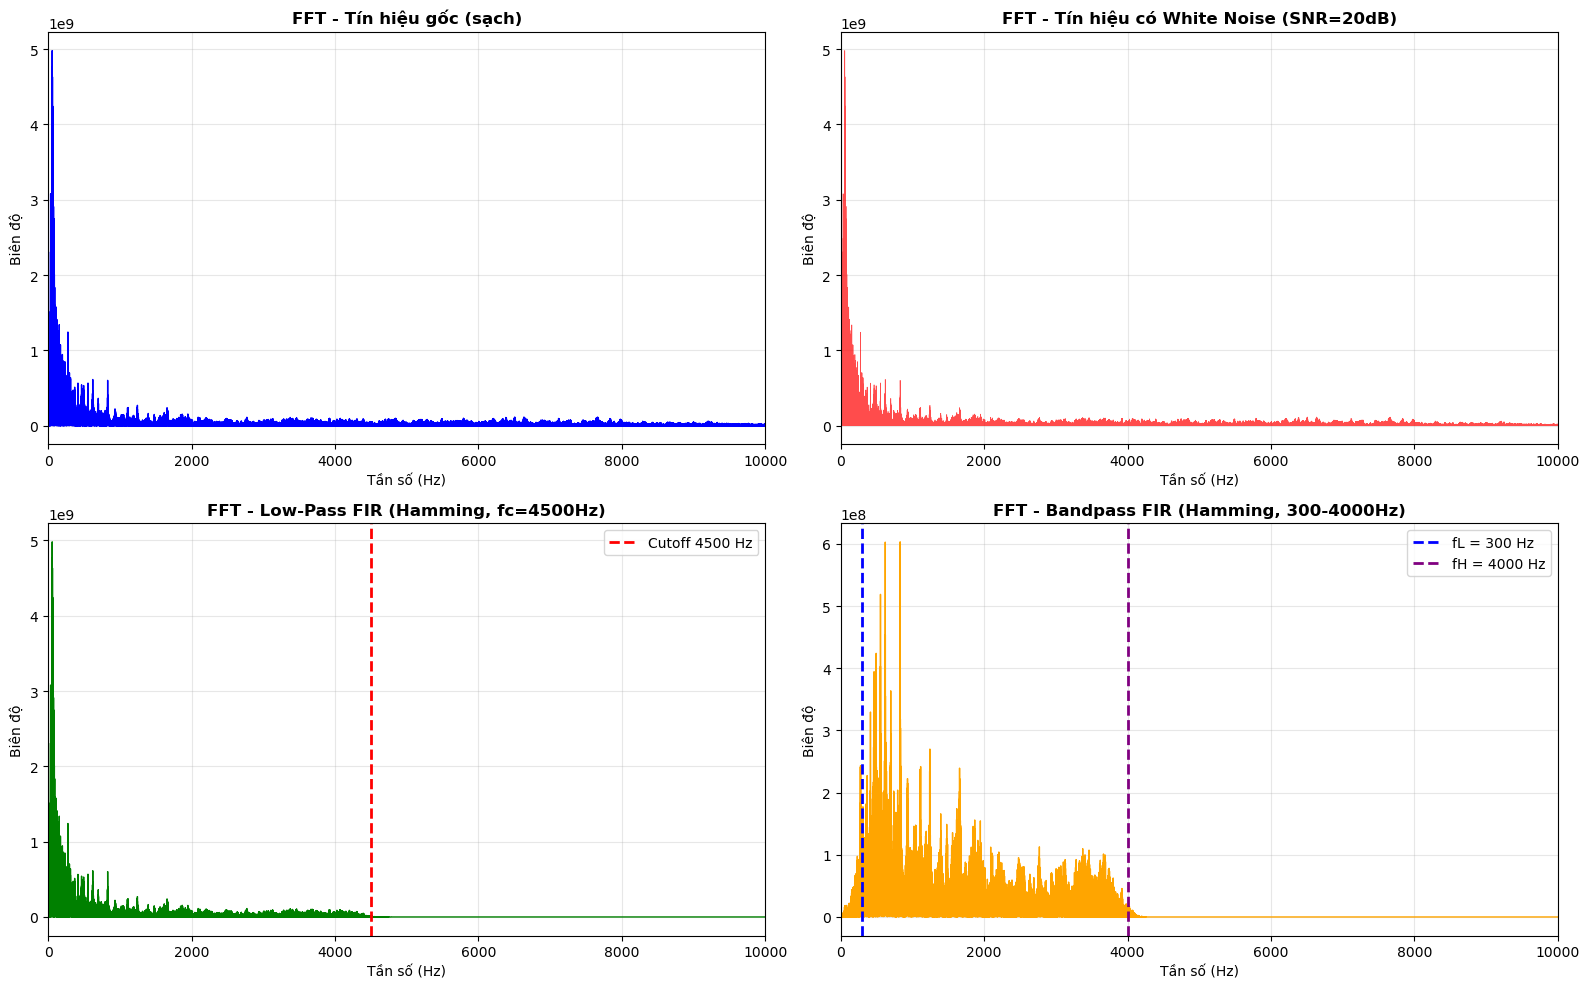

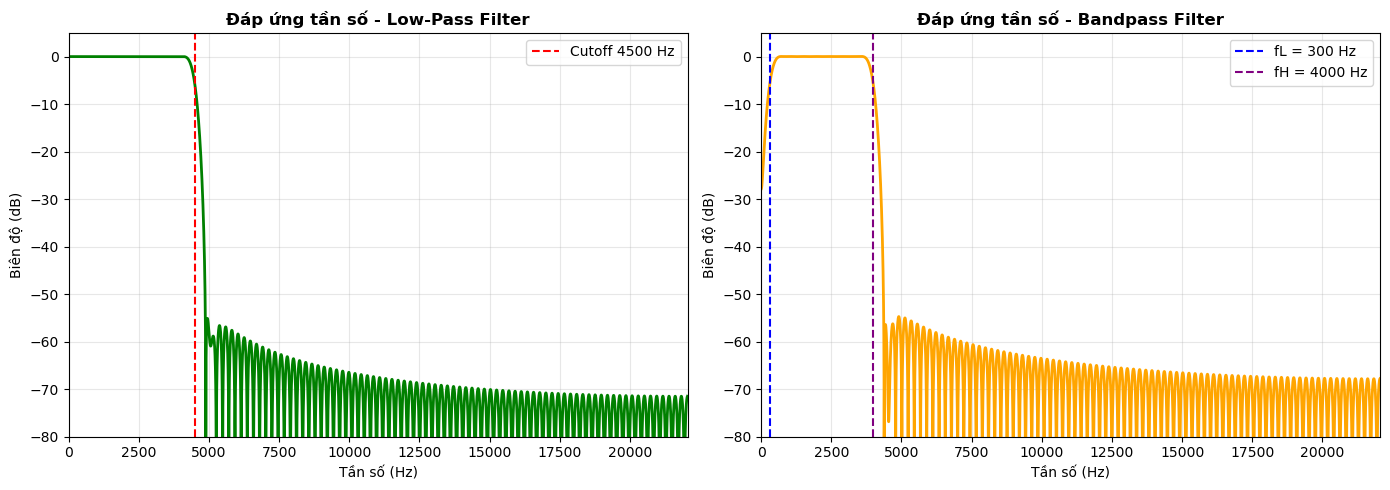

Đã lưu: filtered_lowpass.wav, filtered_bandpass.wav


In [18]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firwin, lfilter, filtfilt, freqz

# Tắt giới hạn output trong Jupyter
try:
    from IPython.display import display, HTML
    display(HTML("<style>.output_area pre {max-height: none !important;}</style>"))
except:
    pass

# ============================================================================
# ĐỌC FILE AUDIO
# ============================================================================
filename = 'smallgirl.wav'
sampleRate, audioData = wavfile.read(filename)
audioData = audioData[:, 0] if audioData.ndim > 1 else audioData
audioData = audioData.astype(np.float64)

# ============================================================================
# CHUẨN HÓA VÀ THÊM WHITE NOISE VỚI SNR = 20 dB
# ============================================================================
max_val = np.max(np.abs(audioData))
audioData_normalized = audioData / max_val
signal_power = np.mean(audioData_normalized ** 2)

SNR_dB = 20
SNR_linear = 10 ** (SNR_dB / 10)
noise_power_required = signal_power / SNR_linear

white_noise = np.random.normal(0, 1, audioData_normalized.shape)
white_noise = white_noise * np.sqrt(noise_power_required)

# Tín hiệu có nhiễu (trở lại thang int16)
audioData_noise = (audioData_normalized + white_noise) * max_val

# ============================================================================
# PHƯƠNG PHÁP 1: FIR LOW-PASS FILTER (4500 Hz) - Hamming Window
# ============================================================================
# Theo bài giảng Chapter 7 (slide 14-16):
#   h_d(n) = h(n - n0) . w(n)_N
#   Hamming window: w(n) = 0.54 - 0.46*cos(2*pi*n / (N-1))
#   firwin() tự động thực hiện các bước này
# ============================================================================
filterOrder = 201
cutoffFrequency = 4500  # Hz
cutoffNormalized = cutoffFrequency / (sampleRate / 2)

b_lp = firwin(filterOrder, cutoffNormalized, window='hamming')
a_lp = 1

# SỬ DỤNG filtfilt THAY CHO lfilter ĐỂ TRÁNH TRỄ PHA
# lfilter: lọc nhân quả, gây group delay = (N-1)/2 = 100 mẫu
# filtfilt: lọc zero-phase (lọc xuôi + lọc ngược), KHÔNG gây trễ
# => Khi tính SNR = filtered - original, không bị lệch mẫu
yn_lowpass = filtfilt(b_lp, a_lp, audioData_noise)

# ============================================================================
# PHƯƠNG PHÁP 2: FIR BANDPASS FILTER (300-4000 Hz) - Hamming Window
# ============================================================================
# Theo bài giảng Chapter 7 (slide 12):
#   Ideal BPF: h(n) = [sin(wH*n) - sin(wL*n)] / (pi*n)
#   Áp dụng Hamming window để truncate thành FIR hữu hạn
# ============================================================================
bandpass_low = 300   # Hz
bandpass_high = 4000  # Hz
bandpass_low_norm = bandpass_low / (sampleRate / 2)
bandpass_high_norm = bandpass_high / (sampleRate / 2)

b_bp = firwin(filterOrder, [bandpass_low_norm, bandpass_high_norm],
              window='hamming', pass_zero=False)
a_bp = 1

yn_bandpass = filtfilt(b_bp, a_bp, audioData_noise)

# ============================================================================
# HÀM PHÂN TÍCH
# ============================================================================
def get_amplitude(sig):
    s = np.array(sig, dtype=np.float64)
    return {
        'max': float(np.max(s)),
        'min': float(np.min(s)),
        'mean': float(np.mean(s)),
        'rms': float(np.sqrt(np.mean(s ** 2)))
    }

def calc_snr(original, processed):
    """Tính SNR = 10*log10(P_signal / P_noise)
    Trong đó P_noise = mean((processed - original)^2)
    """
    o = np.array(original, dtype=np.float64)
    p = np.array(processed, dtype=np.float64)
    noise = p - o
    sig_pow = float(np.mean(o ** 2))
    noi_pow = float(np.mean(noise ** 2))
    snr = float(10 * np.log10(sig_pow / (noi_pow + 1e-10)))
    mse = noi_pow
    rmse = float(np.sqrt(mse))
    return snr, mse, rmse

def print_amp(name, amp):
    print(name + ':')
    print('  Biên độ tối đa:     ' + str(amp['max']))
    print('  Biên độ tối thiểu:  ' + str(amp['min']))
    print('  Biên độ trung bình: ' + str(amp['mean']))
    print('  Biên độ RMS:        ' + str(amp['rms']))

# ============================================================================
# TÍNH TOÁN TẤT CẢ
# ============================================================================
amp_original = get_amplitude(audioData)
amp_noisy = get_amplitude(audioData_noise)
amp_lowpass = get_amplitude(yn_lowpass)
amp_bandpass = get_amplitude(yn_bandpass)

snr_before, mse_before, rmse_before = calc_snr(audioData, audioData_noise)
snr_lp, mse_lp, rmse_lp = calc_snr(audioData, yn_lowpass)
snr_bp, mse_bp, rmse_bp = calc_snr(audioData, yn_bandpass)

noise_rms_original = float(np.sqrt(np.mean((audioData_noise - audioData) ** 2)))
noise_rms_lp = float(np.sqrt(np.mean((yn_lowpass - audioData) ** 2)))
noise_rms_bp = float(np.sqrt(np.mean((yn_bandpass - audioData) ** 2)))

pct_lp = round(noise_rms_lp / noise_rms_original * 100, 2)
pct_bp = round(noise_rms_bp / noise_rms_original * 100, 2)

improve_lp = round(snr_lp - snr_before, 2)
improve_bp = round(snr_bp - snr_before, 2)

# ============================================================================
# IN KẾT QUẢ
# ============================================================================
print('=' * 70)
print('PHÂN TÍCH BIÊN ĐỘ TÍN HIỆU')
print('=' * 70)
print_amp('Tín hiệu gốc', amp_original)
print()
print_amp('Tín hiệu có nhiễu trắng (SNR = ' + str(SNR_dB) + ' dB)', amp_noisy)
print()
print_amp('Tín hiệu đã lọc Low-Pass FIR (4500 Hz, Hamming, N=201)', amp_lowpass)
print()
print_amp('Tín hiệu đã lọc Bandpass FIR (300-4000 Hz, Hamming, N=201)', amp_bandpass)

print()
print('=' * 70)
print('SNR TRƯỚC VÀ SAU KHI LỌC (dùng filtfilt - zero phase)')
print('=' * 70)
print()
print('Trước khi lọc:          SNR = ' + str(round(snr_before, 2)) + ' dB | MSE = ' + str(round(mse_before, 2)) + ' | RMSE = ' + str(round(rmse_before, 2)))
print('Sau Low-Pass (4500Hz):  SNR = ' + str(round(snr_lp, 2)) + ' dB | MSE = ' + str(round(mse_lp, 2)) + ' | RMSE = ' + str(round(rmse_lp, 2)))
print('Sau Bandpass (300-4k):  SNR = ' + str(round(snr_bp, 2)) + ' dB | MSE = ' + str(round(mse_bp, 2)) + ' | RMSE = ' + str(round(rmse_bp, 2)))

print()
print('=' * 70)
print('NHIỄU CÒN LẠI SAU KHI LỌC')
print('=' * 70)
print()
print('Nhiễu gốc (RMS):    ' + str(round(noise_rms_original, 4)))
print('Sau Low-Pass:        ' + str(round(noise_rms_lp, 4)) + ' (còn ' + str(pct_lp) + '%)')
print('Sau Bandpass:        ' + str(round(noise_rms_bp, 4)) + ' (còn ' + str(pct_bp) + '%)')

print()
print('=' * 70)
print('MỨC CẢI THIỆN SNR')
print('=' * 70)
print()
sign_lp = '+' if improve_lp >= 0 else ''
sign_bp = '+' if improve_bp >= 0 else ''
print('Low-Pass:  ' + sign_lp + str(improve_lp) + ' dB so với trước lọc')
print('Bandpass:  ' + sign_bp + str(improve_bp) + ' dB so với trước lọc')
print()
if snr_bp > snr_lp:
    print('=> Bandpass Filter (300-4000 Hz) cho kết quả tốt hơn')
else:
    print('=> Low-Pass Filter (4500 Hz) cho kết quả tốt hơn')

sys.stdout.flush()

# ============================================================================
# VẼ BIỂU ĐỒ FFT SO SÁNH
# ============================================================================
freq_bins = len(audioData_noise)
fft_original = np.abs(np.fft.fft(audioData))[:freq_bins // 2]
fft_noisy = np.abs(np.fft.fft(audioData_noise))[:freq_bins // 2]
fft_lowpass = np.abs(np.fft.fft(yn_lowpass))[:freq_bins // 2]
fft_bandpass = np.abs(np.fft.fft(yn_bandpass))[:freq_bins // 2]
frequencies = np.fft.fftfreq(freq_bins, 1 / sampleRate)[:freq_bins // 2]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(frequencies, fft_original, 'b-', linewidth=1)
axes[0, 0].set_title('FFT - Tín hiệu gốc (sạch)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tần số (Hz)')
axes[0, 0].set_ylabel('Biên độ')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, 10000])

axes[0, 1].plot(frequencies, fft_noisy, 'r-', linewidth=0.5, alpha=0.7)
axes[0, 1].set_title('FFT - Tín hiệu có White Noise (SNR=' + str(SNR_dB) + 'dB)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tần số (Hz)')
axes[0, 1].set_ylabel('Biên độ')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 10000])

axes[1, 0].plot(frequencies, fft_lowpass, 'g-', linewidth=1)
axes[1, 0].axvline(4500, color='red', linestyle='--', linewidth=2, label='Cutoff 4500 Hz')
axes[1, 0].set_title('FFT - Low-Pass FIR (Hamming, fc=4500Hz)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tần số (Hz)')
axes[1, 0].set_ylabel('Biên độ')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 10000])
axes[1, 0].legend()

axes[1, 1].plot(frequencies, fft_bandpass, 'orange', linewidth=1)
axes[1, 1].axvline(300, color='blue', linestyle='--', linewidth=2, label='fL = 300 Hz')
axes[1, 1].axvline(4000, color='purple', linestyle='--', linewidth=2, label='fH = 4000 Hz')
axes[1, 1].set_title('FFT - Bandpass FIR (Hamming, 300-4000Hz)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tần số (Hz)')
axes[1, 1].set_ylabel('Biên độ')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 10000])
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('fft_comparison.png', dpi=150)
plt.show()

# ============================================================================
# VẼ ĐÁP ỨNG TẦN SỐ CỦA BỘ LỌC
# ============================================================================
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đáp ứng tần số Low-Pass
w_lp, h_lp = freqz(b_lp, 1, worN=8000)
freq_lp = w_lp * sampleRate / (2 * np.pi)
ax1.plot(freq_lp, 20 * np.log10(np.abs(h_lp) + 1e-10), 'g-', linewidth=2)
ax1.axvline(4500, color='red', linestyle='--', label='Cutoff 4500 Hz')
ax1.set_title('Đáp ứng tần số - Low-Pass Filter', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tần số (Hz)')
ax1.set_ylabel('Biên độ (dB)')
ax1.set_xlim([0, sampleRate // 2])
ax1.set_ylim([-80, 5])
ax1.grid(True, alpha=0.3)
ax1.legend()

# Đáp ứng tần số Bandpass
w_bp, h_bp = freqz(b_bp, 1, worN=8000)
freq_bp = w_bp * sampleRate / (2 * np.pi)
ax2.plot(freq_bp, 20 * np.log10(np.abs(h_bp) + 1e-10), color='orange', linewidth=2)
ax2.axvline(300, color='blue', linestyle='--', label='fL = 300 Hz')
ax2.axvline(4000, color='purple', linestyle='--', label='fH = 4000 Hz')
ax2.set_title('Đáp ứng tần số - Bandpass Filter', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tần số (Hz)')
ax2.set_ylabel('Biên độ (dB)')
ax2.set_xlim([0, sampleRate // 2])
ax2.set_ylim([-80, 5])
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('filter_response.png', dpi=150)
plt.show()

# ============================================================================
# LƯU FILE
# ============================================================================
wavfile.write('filtered_lowpass.wav', sampleRate, yn_lowpass.astype(np.int16))
wavfile.write('filtered_bandpass.wav', sampleRate, yn_bandpass.astype(np.int16))
print('Đã lưu: filtered_lowpass.wav, filtered_bandpass.wav')